## 3D Inversion of MT Data

Here we will provide a simple synthetic example to demonstrate a 3D inversion using `simpeg`.  More tools exist in `simpeg` to speed up the inversion on high-performance computing, for more details see [simpeg Meta classes](https://docs.simpeg.xyz/latest/content/api/simpeg.meta.html).  

**Note**: Integrating 3D inversion into `mtpy-v2` is still under development.  

### Imports

In [1]:
import warnings
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.colors import LogNorm, Normalize
from ipywidgets import interact, widgets
from pymatsolver import Pardiso as Solver

from discretize.utils import mkvc, refine_tree_xyz

from simpeg import (
    maps, utils, data, optimization, maps, regularization, 
    inverse_problem, directives, inversion, data_misfit
)
from simpeg.electromagnetics import natural_source as nsem

from mtpy_data import FWD_CONDUCTIVE_CUBE_GRID_LIST
from mtpy import MTData 

warnings.filterwarnings("ignore", category=FutureWarning)

### Load Synthetic Data

Again, we are going to look at the conductive block in a layered half-space as in the previous examples for 1D and 2D.


25:07:11T17:44:13 | WARNING | line:191 |mtpy.imaging.plot_stations | plot | Could not add base map because HTTPSConnectionPool(host='basemap.nationalmap.gov', port=443): Max retries exceeded with url: /arcgis/rest/services/USGSTopo/MapServer/tile/14/9634/14549 (Caused by SSLError(SSLCertVerificationError(1, '[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: self-signed certificate in certificate chain (_ssl.c:1006)')))


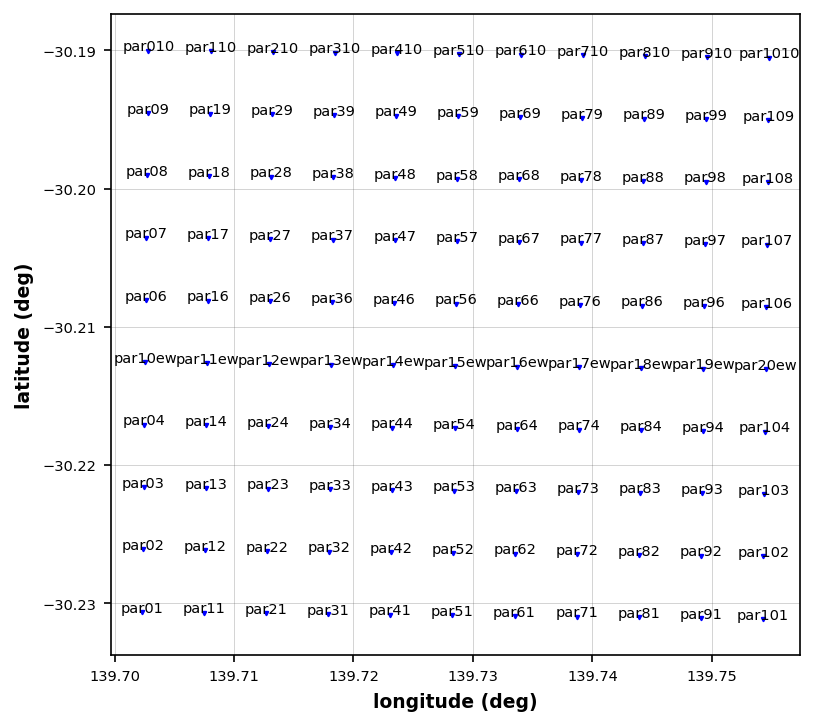

Plotting PlotStations

In [2]:
md = MTData()
md.add_station(FWD_CONDUCTIVE_CUBE_GRID_LIST)
md.utm_epsg = 8059 # need a coordinate reference system, this is the GDA94
md = md.apply_bounding_box(139.70, 139.756, -30.235, -30.188)
md.plot_stations()

### Get subset of data
For a simple toy example we will make the problem smaller down sampling the data so that the inversion will run in a reasonable amount of time.  Here we are taking every other station within the grid.

In [3]:
subset = []
for ii in range(0, 12, 2):
    for jj in range(1, 10, 2):
        if jj == 5:
            if ii >= 10:
                subset.append(f"0.par20ew")
            else:
                subset.append(f"0.par1{ii}ew")
        else:
            subset.append(f"0.par{ii}{jj}")


25:07:11T17:44:15 | WARNING | line:191 |mtpy.imaging.plot_stations | plot | Could not add base map because HTTPSConnectionPool(host='basemap.nationalmap.gov', port=443): Max retries exceeded with url: /arcgis/rest/services/USGSTopo/MapServer/tile/14/9634/14549 (Caused by SSLError(SSLCertVerificationError(1, '[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: self-signed certificate in certificate chain (_ssl.c:1006)')))


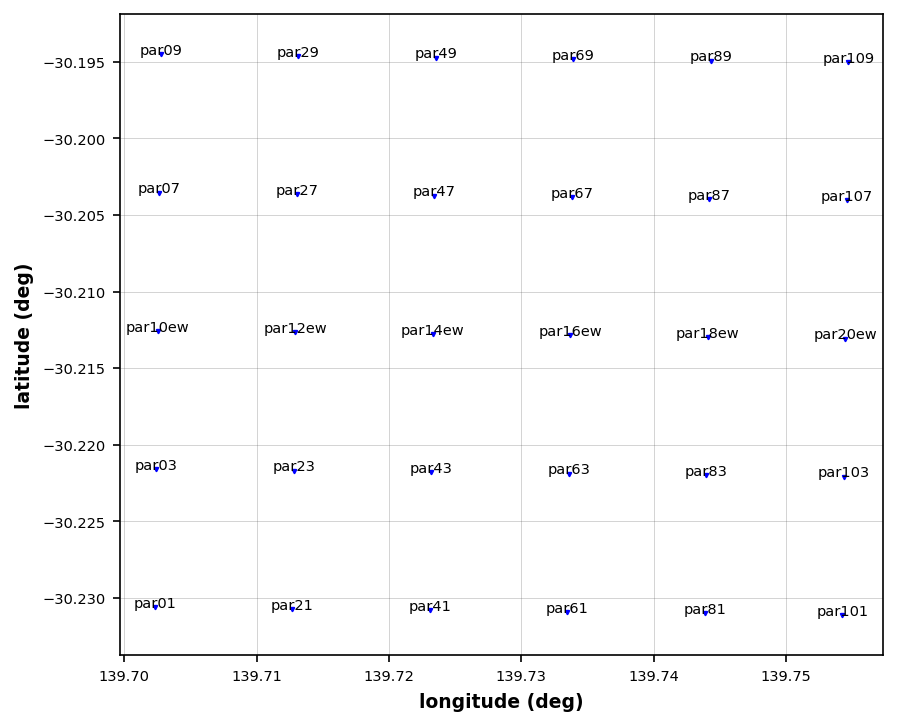

Plotting PlotStations

In [4]:
md = md.get_subset(subset)
md.plot_stations()

### Interpolate Data
Again to speed up compute time we will only invert 2 periods that are sensitive to the conductive body.   

In [5]:
interp_periods = np.array([0.1,  2])
interp_mt_data = md.interpolate(interp_periods, inplace=False)

In [6]:
interp_mt_data.compute_model_errors(z_error_value=5)
interp_mt_data.model_epsg = md.utm_epsg     # need a coordinate reference system, this is the GDA94
interp_mt_data.compute_relative_locations()

### Get Simpeg Data Object

Here we are converting the data to the format that `simpeg` expects.  We are also directing which components to invert and in what coordinate reference frame.  We are choosing to invert only the $Z_{xy}$ and $Z_{yx}$ components, the right-hand components, and we will invert on a relative grid centered at (0, 0, 0).

In [7]:
data_object = interp_mt_data.to_simpeg_3d(
    include_elevation=False,
    invert_z_xx=False,
    invert_z_xy=True,
    invert_z_yx=True,
    invert_z_yy=False,
    invert_t_zx=False,
    invert_t_zy=False,
    geographic_coordinates=False,
)
station_locations = data_object.station_locations

### Make Octree Mesh
One of the advantages of using `simpeg` is that the model mesh is versatile.  Here we will be using an octree mesh that adapts to the station coverage.  The advantages of modeling on an octree mesh are: 

1) size of the model is dramatically reduced
2) can handle non-regularly spaced stations
3) can handle topography much better than a tensor mesh  

There is an art to creating an adequate octree mesh, below is one example of how one might create an octree mesh.  This method attempts to create a mesh that is based on the data, particularly the minimum and maximum frequency to invert and the starting background conductivity.  Using the skin depth equation the function estimates the smallest cell size and deepest depths of penetration.

In [ ]:
import discretize.utils as dis_utils
from discretize import TreeMesh
from geoana.em.fdem import skin_depth


def get_octree_mesh(
    station_locations,   # array of station location [n, 3]
    frequencies,         # frequencies being inverted
    sigma_background,    # conductivity of starting half space model (1/resistivity) 
    station_spacing,     # station spacing in meters
    factor_spacing=4,    # number of cells between station spacing
    factor_x_pad=2,      # pad in the x-direction (east)
    factor_y_pad=2,      # pad in the y-direction (north)
    factor_z_pad_down=2, # pad in the z-direction (z+ up, earth is z- down)
    factor_z_core=1,     # increase number of cells in core z
    factor_z_pad_up=1,   # padding cells in the air
):
    f_min = frequencies.min()
    f_max = frequencies.max()

    # get padding cells
    lx_pad = skin_depth(f_min, sigma_background) * factor_x_pad
    ly_pad = skin_depth(f_min, sigma_background) * factor_y_pad
    lz_pad_down = skin_depth(f_min, sigma_background) * factor_z_pad_down
    lz_pad_up = skin_depth(f_min, sigma_background) * factor_z_pad_up

    # get core cells
    lx_core = station_locations[:, 0].max() - station_locations[:, 0].min()
    ly_core = station_locations[:, 1].max() - station_locations[:, 1].min()
    lz_core = skin_depth(f_min, sigma_background) * factor_z_core

    lx = lx_pad + lx_core + lx_pad
    ly = ly_pad + ly_core + ly_pad
    lz = lz_pad_down + lz_core + lz_pad_up

    # get minimum cell sizes
    dx = station_spacing / factor_spacing
    dy = station_spacing / factor_spacing
    dz = np.round(skin_depth(f_max, sigma_background) / 4, decimals=-1)

    # Compute number of base mesh cells required in x and y
    nbcx = 2 ** int(np.ceil(np.log(lx / dx) / np.log(2.0)))
    nbcy = 2 ** int(np.ceil(np.log(ly / dy) / np.log(2.0)))
    nbcz = 2 ** int(np.ceil(np.log(lz / dz) / np.log(2.0)))

    # build mesh with discretize mesh builder
    mesh = dis_utils.mesh_builder_xyz(
        station_locations,
        [dx, dy, dz],
        padding_distance=[[lx_pad, lx_pad], [ly_pad, ly_pad], [lz_pad_down, lz_pad_up]],
        depth_core=lz_core,
        mesh_type="tree",
    )

    # refine topography, flat earth here, but will discretize closer to the surface
    X, Y = np.meshgrid(mesh.nodes_x, mesh.nodes_y)
    topo = np.c_[X.flatten(), Y.flatten(), np.zeros(X.size)]
    mesh.refine_surface(
        topo, padding_cells_by_level=[0, 0, 2], finalize=False
    )
    mesh.refine_surface(station_locations, padding_cells_by_level=[1, 2, 1], finalize=True)

    return mesh

Make the mesh using `get_octree_mesh` providing a few parameters from the data.

In [ ]:
mesh = get_octree_mesh(
    station_locations,
    data_object.frequencies,
    1e-2,              # starting conductivity value
    1000,              # station spacing in meters 
    factor_spacing=4,  # factor for adding cells with in station area, the higher the number the more cells. 
)
print(f"Number of model cells is: {mesh.nC}")

Number of model cells is: 193344


Play around with the parameters to get a model that is adequate for the problem and knowing the memory of your compute architecture.  This size model will take about 15 minutes to run.

Now set the cells above the surface to the value of air and identify the active cells to invert for, the subsurface cells that are considered free.

In [25]:
sigma_background = np.ones(mesh.nC) * 1e-8
ind_active = mesh.cell_centers[:,2] < 0.
sigma_background[ind_active] = 1e-2
print(f"The number of active cells is: {ind_active.sum()}")

The number of active cells is: 170304


Plot the created octree mesh.

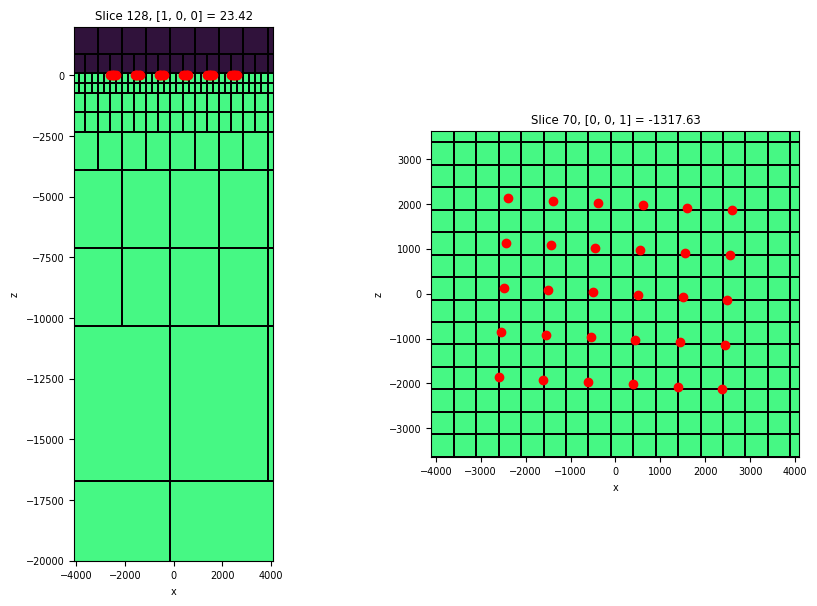

In [26]:
fig, ax = plt.subplots(1, 2, figsize=(10, 6))
ax1, ax2 = ax
pad = 1500

mesh.plot_slice(
    sigma_background,
    grid=True,
    normal="X",
    ax=ax1,
    pcolor_opts={"cmap": "turbo", "norm": LogNorm(vmin=1e-4, vmax=10)},
    grid_opts={"lw": 0.1, "color": "k"},
    range_x=(
        station_locations[:, 0].min() - pad,
        station_locations[:, 0].max() + pad,
    ),

    range_y=(-20000, 20000 * 0.1),
)
ax1.plot(
    station_locations[:, 0],
    station_locations[:, 2],
    "ro",
)

ax1.set_aspect(1)

# plot map view
mesh.plot_slice(
    sigma_background,
    grid=True,
    normal="Z",
    ax=ax2,
    slice_loc=-1500,
    pcolor_opts={"cmap": "turbo", "norm": LogNorm(vmin=1e-4, vmax=10)},
    grid_opts={"lw": 0.1, "color": "k"},
    range_x=(
        station_locations[:, 0].min() - pad,
        station_locations[:, 0].max() + pad,
    ),
    range_y=(
        station_locations[:, 1].min() - pad,
        station_locations[:, 1].max() + pad,
    ),
)
ax2.plot(
    station_locations[:, 0],
    station_locations[:, 1],
    "ro",
)
ax2.set_aspect(1)

#### Set up Inversion

##### Data
We have already setup the data, but now we need to organize it the way that `simpeg` expects.  So we need to provide `simpeg` with the source objects (the fields to caclulate) and the sources geometry (station location).  These are done in the `mtpy-v2 data_object`.  We will explicitly make them variables.

In [ ]:

ns_data = data_object.get_simpeg_data_object()
ns_data.standard_deviation = np.abs(ns_data.dobs * .01)  # provide some error floors for the inversion.
src_list = ns_data.survey.source_list
survey = ns_data.survey

Now we can plot the data and error floors.  This plot is a little confusing because it is plotting all data and all periods.  The array is ordered by period and then by component.

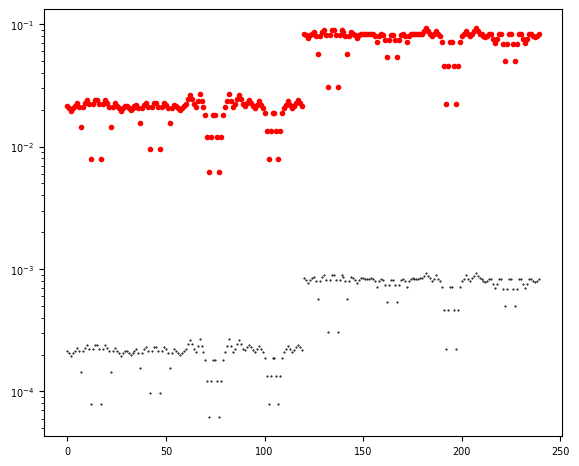

In [ ]:
# data_object.standard_deviation = stdnew.flatten()  # sim.survey.std
plt.semilogy(abs(ns_data.dobs), '.r')
plt.semilogy((ns_data.standard_deviation), 'k.', ms=1)
plt.ylabel("Impedance Amplitude")
plt.xlabel("Data point index")
plt.show()

##### Forward Problem

Here we are setting up the forward problem.  We provide which cells to invert for through mapping the half-space conductivity model onto the octree mesh, and which fields to calculate.

In [ ]:
# Set the mapping
active_map = maps.InjectActiveCells(
    mesh=mesh, indActive=ind_active, valInactive=np.log(1e-8)
)
mapping = maps.ExpMap(mesh) * active_map

# Setup the problem object
simulation = nsem.simulation.Simulation3DPrimarySecondary(
    mesh,
    survey=survey,
    sigmaMap=mapping,
    sigmaPrimary=sigma_background,
    solver=Solver

)

##### Setup and Run Inversion

Now that we have the data, octree mesh, and forward problem setup, let's setup the inversion.



In [ ]:
# Optimization
opt = optimization.ProjectedGNCG(maxIter=10, maxIterCG=20, upper=np.inf, lower=-np.inf)
opt.remember('xc')

# Data misfit
dmis = data_misfit.L2DataMisfit(data=ns_data, simulation=simulation)

# Regularization
# set up regularization mapping
regmap = maps.IdentityMap(nP=int(ind_active.sum()))  
reg = regularization.Sparse(mesh, active_cells=ind_active, mapping=regmap)

dz = mesh.h[2].min()
dx = mesh.h[0].min()

reg.alpha_s = 1e-8      # starting smallness
reg.alpha_x = dz/dx     # smoothing in x-direction (east) 
reg.alpha_y = dz/dx     # smoothing in y-direction (northing)
reg.alpha_z = 1.        # smoothing in z-direction

# Inverse problem
inv_prob = inverse_problem.BaseInvProblem(dmis, reg, opt)

# Beta schedule
beta = directives.BetaSchedule(coolingRate=1, coolingFactor=2)

# Initial estimate of beta
beta_est = directives.BetaEstimate_ByEig(beta0_ratio=1e0)

# Target misfit stop
target = directives.TargetMisfit()

# Create an inversion object and save each iteration results to a dictionary
save_dictionary = directives.SaveOutputDictEveryIteration()
directive_list = [beta, beta_est, target, save_dictionary]
inv = inversion.BaseInversion(inv_prob, directiveList=directive_list)

# Set an intitial guess
m_0 = np.log(sigma_background[ind_active])

# Run the inversion
mopt = inv.run(m_0)

print(f"Final normalized RMS: {(abs(ns_data.dobs - inv_prob.dpred)/ns_data.standard_deviation).mean()}")



Running inversion with SimPEG v0.23.0
simpeg.InvProblem will set Regularization.reference_model to m0.
simpeg.InvProblem will set Regularization.reference_model to m0.
simpeg.InvProblem will set Regularization.reference_model to m0.
simpeg.InvProblem will set Regularization.reference_model to m0.

                        simpeg.InvProblem is setting bfgsH0 to the inverse of the eval2Deriv.
                        ***Done using same Solver, and solver_opts as the Simulation3DPrimarySecondary problem***
                        
model has any nan: 0
=============================== Projected GNCG ===============================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS    Comment   
-----------------------------------------------------------------------------
x0 has any nan: 0
   0  3.47e-02  3.19e+05  0.00e+00  3.19e+05    6.28e+04      0              
   1  1.73e-02  1.42e+04  2.69e+05  1.88e+04    6.78e+03      0              
   2  8.67e-03  4.67e+03  2.78e+05  7

##### Plot Results

First plot the model response versus the data, again another confusing plot.  

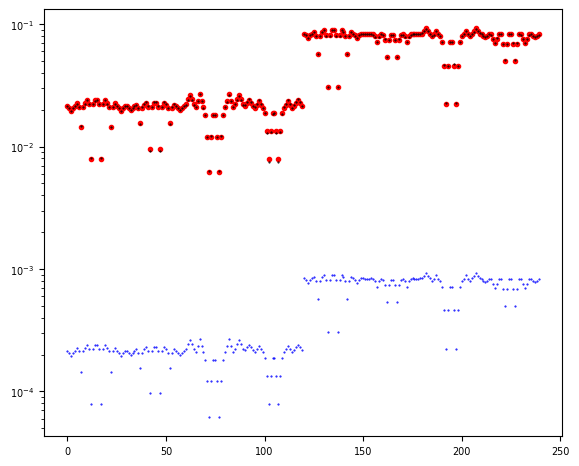

In [17]:
# data_object.standard_deviation = stdnew.flatten()  # sim.survey.std
plt.semilogy(abs(ns_data.dobs), '.r')
plt.semilogy(abs(inv_prob.dpred), 'k.', ms=1)
plt.semilogy(abs(ns_data.standard_deviation), 'b.', ms=1)
plt.show()

In [18]:
iteration = len(save_dictionary.outDict)
m = save_dictionary.outDict[iteration]['m']
sigma_est = mapping*m
pred = save_dictionary.outDict[iteration]['dpred']

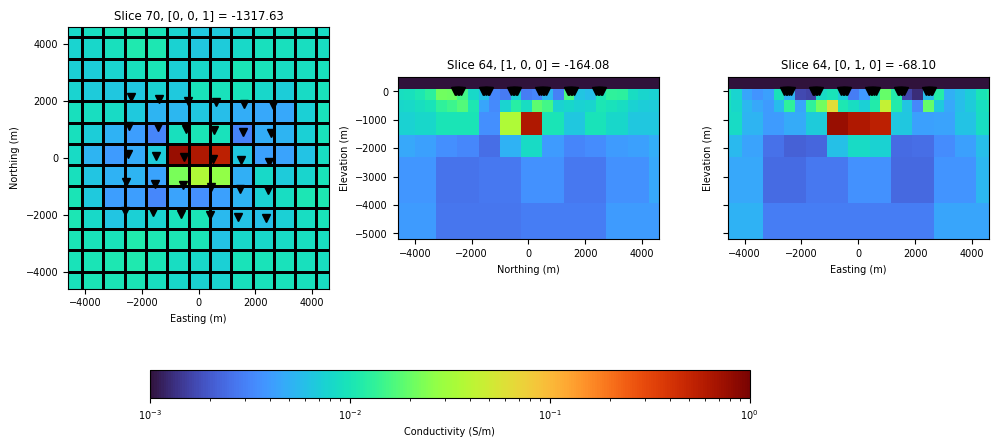

In [21]:
fig, axs = plt.subplots(1,3, figsize=(10, 8))
ax1, ax2, ax3 = axs
ax4 = fig.add_axes([.15, .2, .6, .035])
z_loc = -1500.
y_loc = 0
x_loc = 0
pad = 2000

# depth slice
mesh.plot_slice(
    sigma_est, grid=True, normal='Z', ax=ax1,
    pcolor_opts={"cmap":"turbo", "norm":LogNorm(vmin=1e-3, vmax=1)},
    range_x=(station_locations[:,0].min()-pad, station_locations[:,0].max()+pad), 
    range_y=(station_locations[:,0].min()-pad, station_locations[:,0].max()+pad), 
    slice_loc=z_loc
)

ax1.plot(station_locations[:,0], station_locations[:,1], 'kv')
ax1.set_aspect(1)
ax1.set_xlabel("Easting (m)")
ax1.set_ylabel("Northing (m)")

# plot X normal north south cross section
lx_core = station_locations[:,0].max() - station_locations[:,0].min()
p1 = mesh.plot_slice(
    sigma_est, grid=False, normal='X', ax=ax2,
    pcolor_opts={"cmap":"turbo", "norm":LogNorm(vmin=1e-3, vmax=1)},
    range_x=(station_locations[:,0].min()-pad, station_locations[:,0].max()+pad), 
    range_y=(-lx_core, lx_core*0.1),
    slice_loc=y_loc
)
ax2.set_xlabel("Northing (m)")
ax2.set_ylabel("Elevation (m)")
plt.colorbar(p1[0], cax=ax4, label="Conductivity (S/m)", orientation="horizontal")

# plot Y normal, east-west cross section
mesh.plot_slice(
    sigma_est, grid=False, normal='Y', ax=ax3,
    pcolor_opts={"cmap":"turbo", "norm":LogNorm(vmin=1e-3, vmax=1)},
    range_x=(station_locations[:,0].min()-pad, station_locations[:,0].max()+pad), 
    range_y=(-lx_core, lx_core*0.1),
    slice_loc=y_loc
)
ax3.set_yticklabels([])
ax3.set_xlabel("Easting (m)")
ax3.set_ylabel("Elevation (m)")
for ax in [ax2, ax3]:
    ax.plot(station_locations[:,0], station_locations[:,2], 'kv')
    ax.set_aspect(1)

fig.tight_layout()